
Our dataset consists of clinical data from patients who entered the hospital complaining of chest pain ("angina") during exercise.  The information collected includes:

* `age` : Age of the patient

* `sex` : Sex of the patient

* `cp` : Chest Pain type

    + Value 0: asymptomatic
    + Value 1: typical angina
    + Value 2: atypical angina
    + Value 3: non-anginal pain
   
    
* `trtbps` : resting blood pressure (in mm Hg)

* `chol` : cholesterol in mg/dl fetched via BMI sensor

* `restecg` : resting electrocardiographic results

    + Value 0: normal
    + Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    + Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

* `thalach` : maximum heart rate achieved during exercise

* `output` : the doctor's diagnosis of whether the patient is at risk for a heart attack
    + 0 = not at risk of heart attack
    + 1 = at risk of heart attack

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt
from plotnine import ggplot, aes, geom_point, labs, theme_bw

In [2]:
ha = pd.read_csv("https://www.dropbox.com/s/aohbr6yb9ifmc8w/heart_attack.csv?dl=1")

## Q1: Natural Multiclass Models

Fit a multiclass KNN, Decision Tree, and LDA for the heart disease data; this time predicting the type of chest pain (categories 0 - 3) that a patient experiences.  For the decision tree, plot the fitted tree, and interpret the first couple splits.


KNN accuracy: 0.451
Decision Tree accuracy: 0.473
LDA accuracy: 0.542


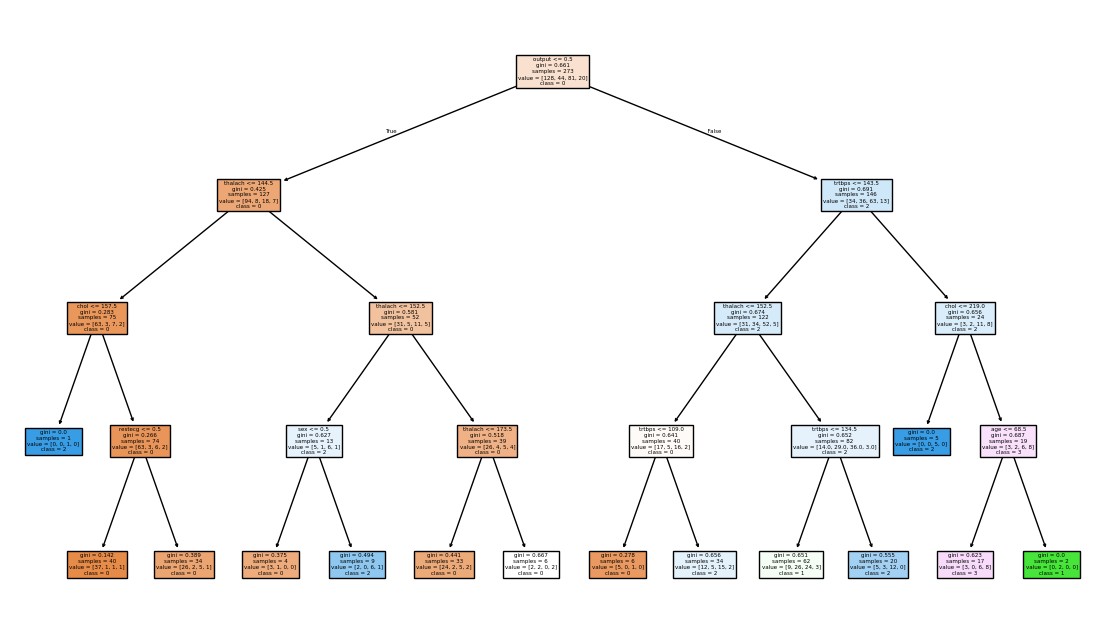

In [3]:
X = ha.drop(columns=['cp', 'Name'], errors='ignore')
y = ha['cp']

# KNN (multiclass)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)
knn_acc = np.mean(cross_val_score(knn, X, y, cv=5))

# Decision Tree (multiclass)
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X, y)
tree_acc = np.mean(cross_val_score(tree, X, y, cv=5))

# LDA (multiclass)
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)
lda_acc = np.mean(cross_val_score(lda, X, y, cv=5))

print(f"KNN accuracy: {knn_acc:.3f}")
print(f"Decision Tree accuracy: {tree_acc:.3f}")
print(f"LDA accuracy: {lda_acc:.3f}")

# Plot decision tree
plt.figure(figsize=(14,8))
plot_tree(tree, feature_names=X.columns, class_names=['0','1','2','3'], filled=True)
plt.show()


## Q2:  OvR

Create a new column in the `ha` dataset called `cp_is_3`, which is equal to `1` if the `cp` variable is equal to `3` and `0` otherwise.

Then, fit a Logistic Regression to predict this new target, and report the **F1 Score**.

Repeat for the other three `cp` categories.  Which category was the OvR approach best at distinguishing?

In [4]:
results = {}
for category in range(4):
    ha[f'cp_is_{category}'] = (ha['cp'] == category).astype(int)
    y_bin = ha[f'cp_is_{category}']
    X_bin = ha.drop(columns=['cp', f'cp_is_{category}', 'Name'], errors='ignore')
    X_train, X_test, y_train, y_test = train_test_split(X_bin, y_bin, test_size=0.3, random_state=42)
    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_train, y_train)
    preds = logreg.predict(X_test)
    f1 = f1_score(y_test, preds)
    results[f'cp_{category}'] = f1
    print(f'F1 Score for cp={category}: {f1:.3f}')
best_cat = max(results, key=results.get)
print("OvR was best at distinguishing:", best_cat, "with F1 =", results[best_cat])

F1 Score for cp=0: 0.720
F1 Score for cp=1: 0.000
F1 Score for cp=2: 0.880
F1 Score for cp=3: 0.571
OvR was best at distinguishing: cp_2 with F1 = 0.88


## Q3: OvO

Reduce your dataset to only the `0` and `1` types of chest pain.

Then, fit a Logistic Regression to predict between the two groups, and report the **ROC-AUC**.  

Repeat comparing category `0` to `2` and `3`.  Which pair was the OvO approach best at distinguishing?

In [5]:
ov_pairs = [(0, 1), (0, 2), (0, 3)]
roc_aucs = {}
for pair in ov_pairs:
    mask = ha['cp'].isin(pair)
    X_ovo = ha.loc[mask].drop(columns=['cp', 'Name'], errors='ignore')
    y_ovo = ha.loc[mask, 'cp']
    # Binary encode (lowest value is 0, highest is 1)
    y_ovo_bin = (y_ovo == pair[1]).astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X_ovo, y_ovo_bin, test_size=0.3, random_state=42)
    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_train, y_train)
    roc = roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1])
    roc_aucs[str(pair)] = roc
    print(f"ROC-AUC for cp {pair[0]} vs cp {pair[1]}: {roc:.3f}")
best_pair = max(roc_aucs, key=roc_aucs.get)
print("OvO was best at distinguishing:", best_pair, "with ROC-AUC =", roc_aucs[best_pair])

ROC-AUC for cp 0 vs cp 1: 1.000
ROC-AUC for cp 0 vs cp 2: 1.000
ROC-AUC for cp 0 vs cp 3: 1.000
OvO was best at distinguishing: (0, 1) with ROC-AUC = 1.0
